In [1]:
%load_ext autoreload
%autoreload 2

In [17]:
import h5py, os
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt

from msi.gaussian_mixture.gaussian_mixture_model import ConditionalGMM
from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters

In [3]:
method_label = "gaussian_mixture"

# network predictions

### choose a run

In [4]:
base_dir = "/pscratch/sd/a/athomsen/run_files/v3"
# base_dir = "/Users/arne/data/DESY3/models/v3/"

In [5]:
# # clustering only
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"
# n_steps = 50000
# params = ["Om", "s8", "bg", "n_bg"]

In [6]:
# # clustering only, with and without survey systematics
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

# # without survey systematics
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}_no_survey_systematics.h5")

# with h5py.File(preds_file, "r") as f:
#     # fiducial
#     no_survey_systematics_fidu_vali_preds = f["fiducial/vali/pred"][:]
    
# print(no_survey_systematics_fidu_vali_preds.shape)


In [7]:
# lensing only
model_dir = "2023-05-29_09-55-49_resnet_vanilla"
n_steps = 50000
params = ["Om", "s8", "Aia", "n_Aia"]

In [8]:
# # combined probes
# model_dir = "2023-05-30_10-56-53_resnet_vanilla"
# n_steps = 10000
# params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

### general

In [9]:
fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = input_output.load_preds(base_dir, model_dir, n_steps)

out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_gaussian_mixture"

23-07-04 10:40:34 input_output INF   Array shapes:
 
23-07-04 10:40:34 input_output INF   fidu_train_preds =   (750, 4) 
23-07-04 10:40:34 input_output INF   fidu_vali_preds =    (50, 4) 
23-07-04 10:40:34 input_output INF   grid_preds =         (2499, 16, 4) 
23-07-04 10:40:34 input_output INF   grid_cosmos =        (2499, 4) 
23-07-04 10:40:34 input_output INF   grid_sobol =         (2499, 4) 


### observation

In [10]:
obs_pred = np.median(fidu_vali_preds, axis=0)

# Gaussian mixture model

In [11]:
preds = np.concatenate(grid_preds, axis=0)
thetas = np.repeat(grid_cosmos, preds.shape[0]//grid_cosmos.shape[0], axis=0)

print(preds.shape)
print(thetas.shape)

(39984, 4)
(39984, 4)


In [12]:
# p(y | x) <=> p(summary | theta)
model = ConditionalGMM(
    # theta
    x_dim=thetas.shape[1],
    # summary
    y_dim=preds.shape[1],
    out_dir="/pscratch/sd/a/athomsen/run_files/debug/GMM",
    n_gaussians=4,
    u_units=256,
    n_layers=3,
    activation="relu",
    input_noise_sig=0.0,
    tune_hyperparams=False,
)

23-07-04 10:40:36 gaussian_mix INF   Created GMM model with n_params = 214076 
Model: "gaussian_mixture_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise (GaussianNoi  (None, 4)                0         
 se)                                                             
                                                                 
 dense (Dense)               (None, 256)               1280      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (N

In [13]:
fit_history = model.fit(
    x=thetas,
    y=preds,
    epochs=300,
    batch_size=2499,
)

23-07-04 10:40:36 gaussian_mix INF   Fitted the x and y scalers 


epoch: 100%|██████████| 300/300 [00:31<00:00,  9.48it/s, loss=-10, val_loss=-9.81, lr=None]  


23-07-04 10:41:08 gaussian_mix INF   Finished training 
23-07-04 10:41:08 gaussian_mix INF   Saved the model in /pscratch/sd/a/athomsen/run_files/debug/GMM 


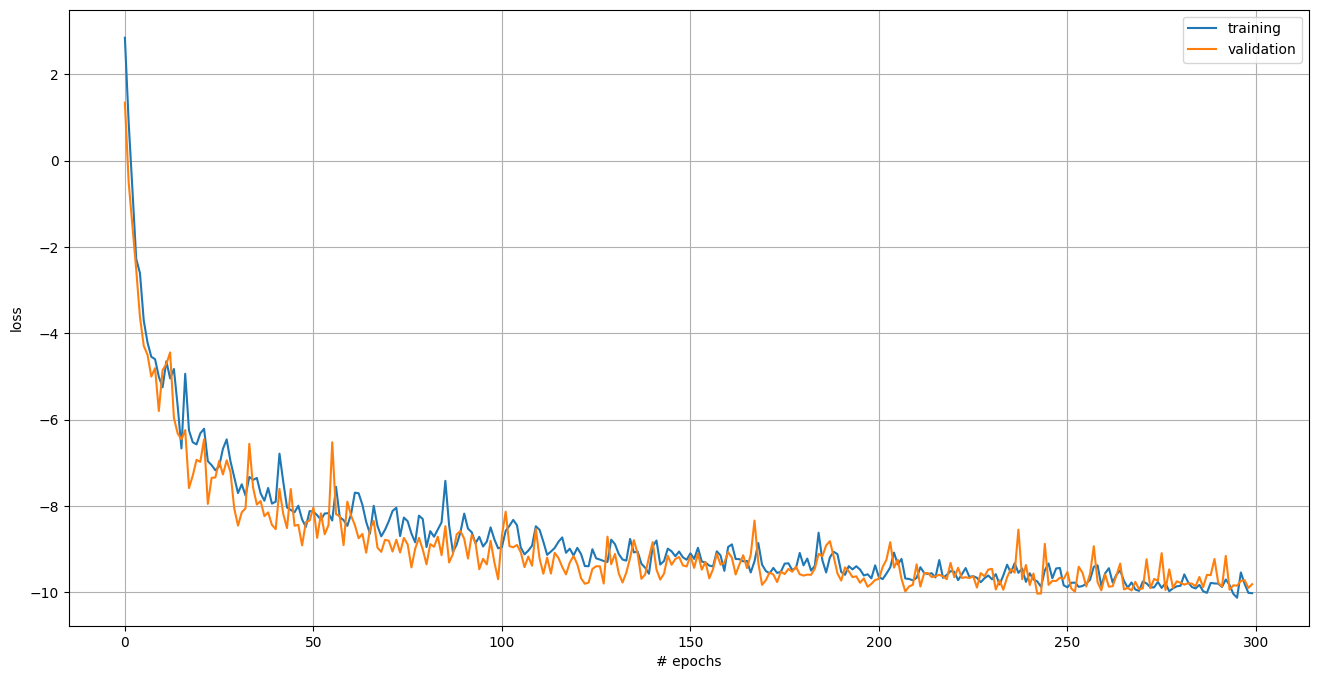

In [14]:
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(fit_history.history["loss"], label="training")
ax.plot(fit_history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="linear")
ax.grid(True)

## MCMC

In [19]:
tf_pred = tf.cast(obs_pred, dtype=tf.float32)
tf_pred = tf.expand_dims(tf_pred, axis=0)

def log_likelihood(X): 
    # evaluate the normal distribution
    log_prob = model.log_likelihood(X, tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)

    return log_prob

In [20]:
chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
)

23-07-04 10:42:10      mcmc.py INF   Initial values in prior: True 


100%|██████████| 1000/1000 [02:11<00:00,  7.63it/s]


## plot

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

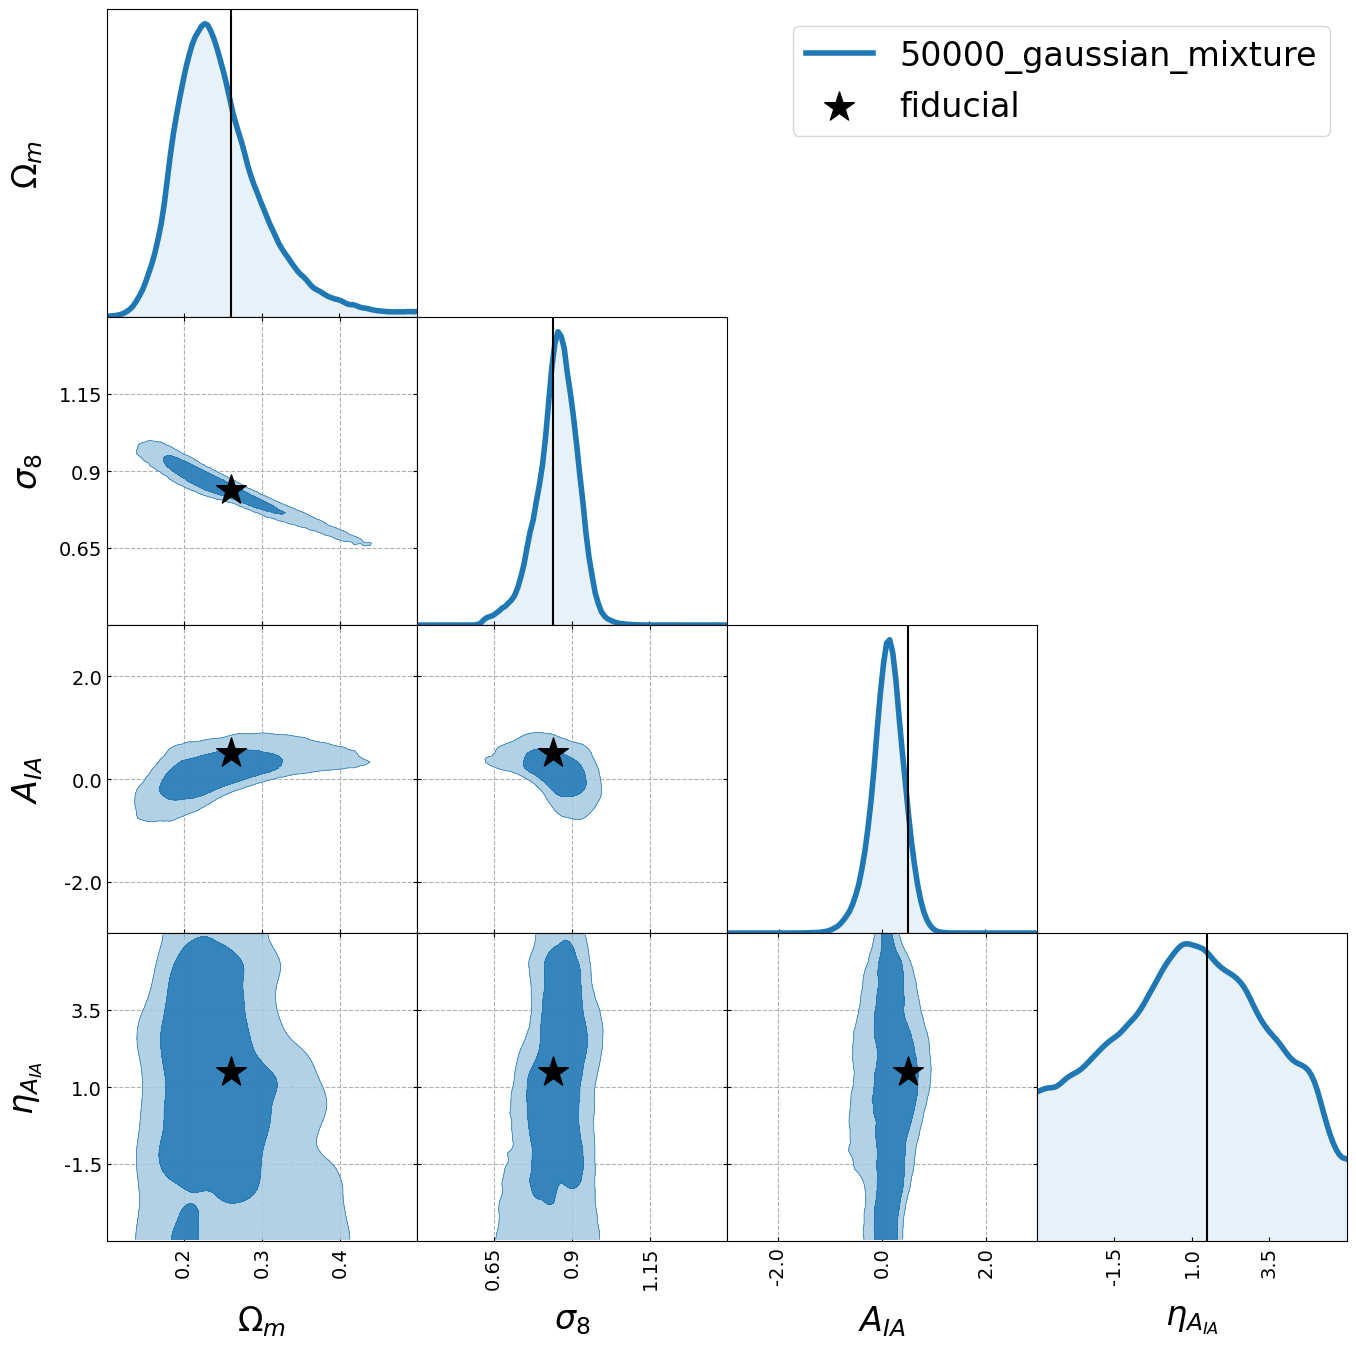

In [23]:
plotting.plot_chain(
    chain, 
    params, 
    out_dir=out_dir, 
    label=label,
)